In [1]:
# Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv('PS_20174392719_1491204439457_log.csv')

# **Exploratory Data Analysis (EDA)**

In [3]:
# Print the first 5 rows to see what the data looks like
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# Check the exact count of Normal vs Fraudulent transactions
fraud_counts = df['isFraud'].value_counts()
print("\nTransaction Counts:")
print(f"Normal Transactions (0): {fraud_counts[0]}")
print(f"Fraudulent Transactions (1): {fraud_counts[1]}")


Transaction Counts:
Normal Transactions (0): 6354407
Fraudulent Transactions (1): 8213


/tmp/ipykernel_4838/84965680.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='isFraud', palette='Set2')


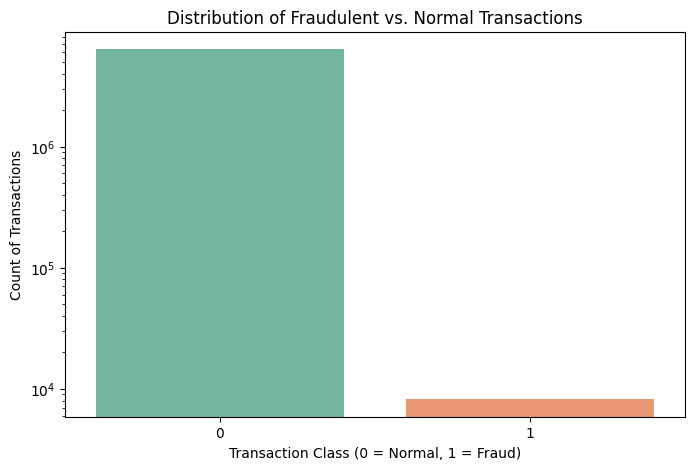

In [5]:
# Create a visualization of the imbalance
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='isFraud', palette='Set2')
plt.title('Distribution of Fraudulent vs. Normal Transactions')
plt.xlabel('Transaction Class (0 = Normal, 1 = Fraud)')
plt.ylabel('Count of Transactions')
plt.yscale('log') # I used a logarithmic scale because the difference is so massive
plt.show()

In [6]:
# Check for missing values across all columns
print("Missing Values per Column:")
print(df.isnull().sum())
print("-" * 30)

Missing Values per Column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
------------------------------


In [7]:
# Isolate and count which transaction 'types' are actually used for fraud
fraud_only = df[df['isFraud'] == 1]
fraud_by_type = fraud_only['type'].value_counts()

print("\nFraudulent Transactions by Type:")
print(fraud_by_type)
print("-" * 30)


Fraudulent Transactions by Type:
type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64
------------------------------


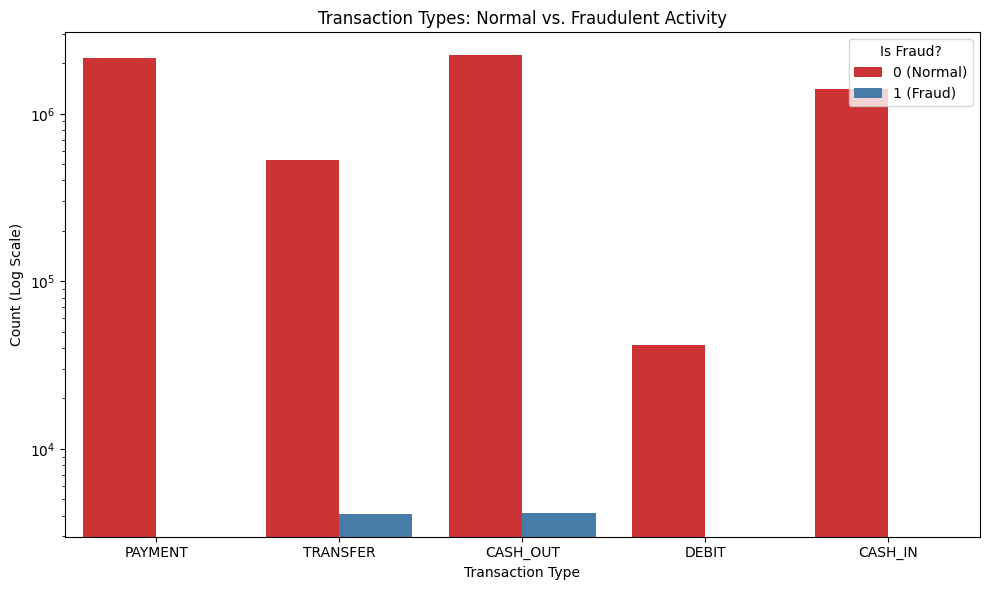

In [8]:
# Create a visualization comparing transaction types
plt.figure(figsize=(10, 6))
# I used a log scale again so the massive normal bars don't completely hide the fraud bars
sns.countplot(data=df, x='type', hue='isFraud', palette='Set1')
plt.title('Transaction Types: Normal vs. Fraudulent Activity')
plt.xlabel('Transaction Type')
plt.ylabel('Count (Log Scale)')
plt.yscale('log')
plt.legend(title='Is Fraud?', labels=['0 (Normal)', '1 (Fraud)'])
plt.tight_layout()
plt.show()

In [9]:
# Filter the data to remove noise
# Since we proved fraud only happens in TRANSFER and CASH_OUT, should remove the other types so they don't confuse our correlation matrix.
df_filtered = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

In [10]:
# Select only the numerical columns for the correlation matrix
numerical_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']
df_corr = df_filtered[numerical_cols]

In [11]:
# Calculate the correlation matrix
correlation_matrix = df_corr.corr()

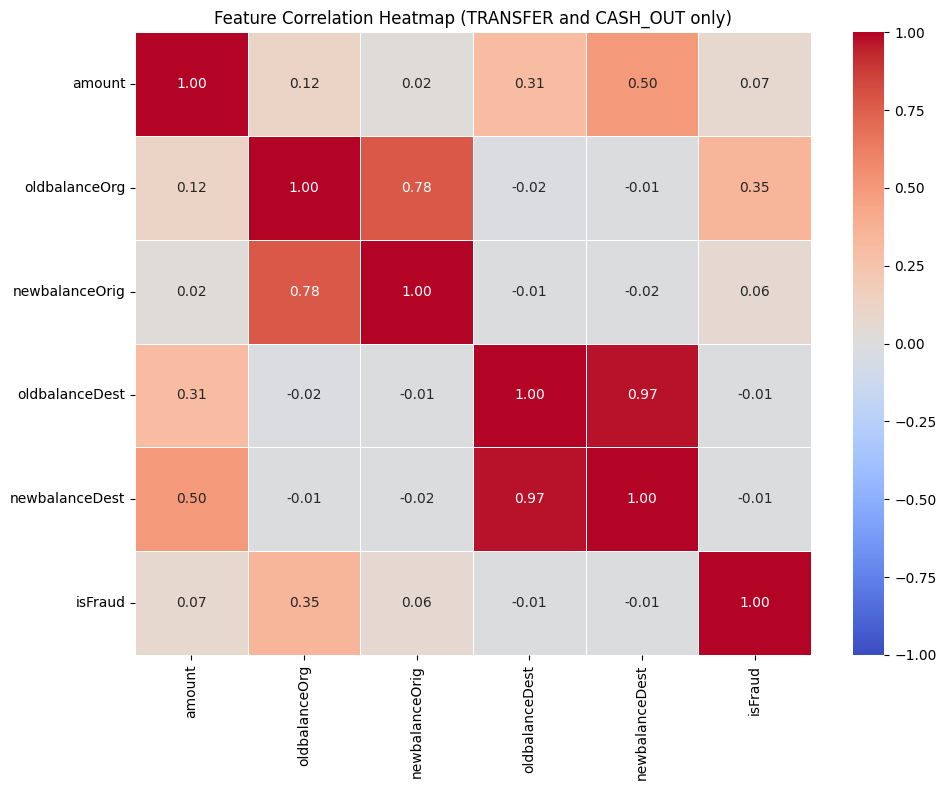

In [12]:
# Create a Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap (TRANSFER and CASH_OUT only)')
plt.tight_layout()
plt.show()

In [13]:
# Prove the "Emptying the Account" hypothesis
# check how many fraudulent transactions completely empty the origin account
fraud_data = df_filtered[df_filtered['isFraud'] == 1]
emptied_accounts = fraud_data[fraud_data['amount'] == fraud_data['oldbalanceOrg']]

print("\nFraudulent Behavior Analysis:")
print(f"Total Fraudulent Transactions: {len(fraud_data)}")
print(f"Fraudulent Transactions that exactly emptied the account: {len(emptied_accounts)}")
print(f"Percentage of fraud that empties accounts: {(len(emptied_accounts)/len(fraud_data))*100:.2f}%")


Fraudulent Behavior Analysis:
Total Fraudulent Transactions: 8213
Fraudulent Transactions that exactly emptied the account: 8034
Percentage of fraud that empties accounts: 97.82%


In [14]:
import warnings
warnings.filterwarnings('ignore') # Hides annoying pandas warnings

In [15]:
# continue using our df_filtered (which only has TRANSFER and CASH_OUT)
# The 'step' column is in hours. We use modulo 24 (% 24) to convert it to a 24-hour clock.
df_filtered['hour_of_day'] = df_filtered['step'] % 24

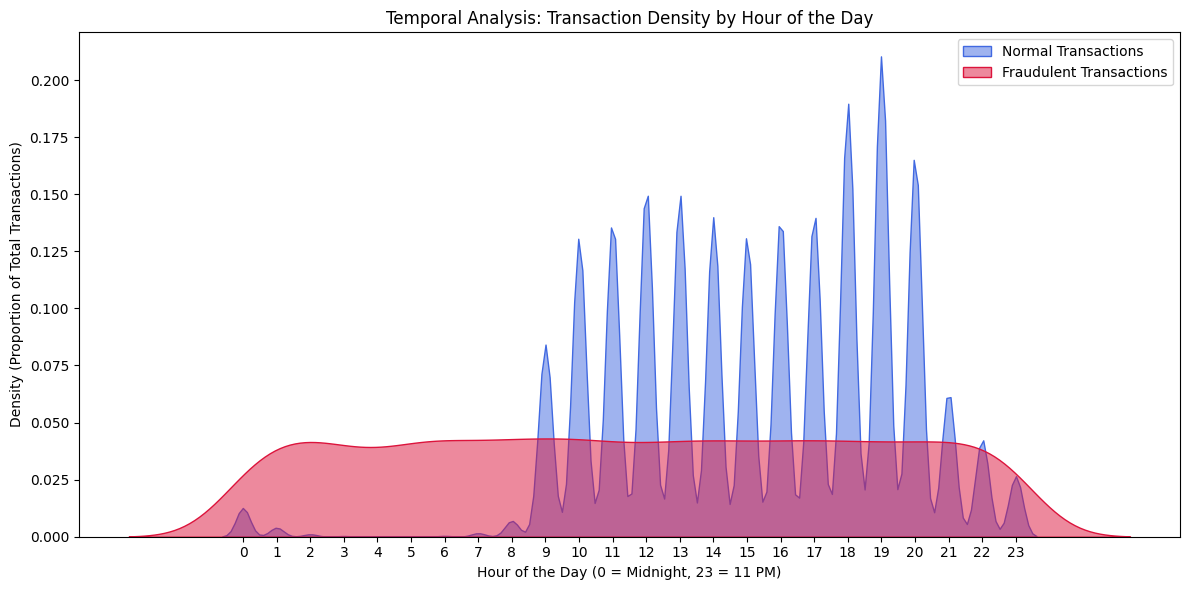

In [16]:
# Create a Density Plot (KDE) to show the flow of time
plt.figure(figsize=(12, 6))

# Plot the density of normal transactions (Blue)
sns.kdeplot(df_filtered[df_filtered['isFraud'] == 0]['hour_of_day'],
            label='Normal Transactions', fill=True, color='royalblue', alpha=0.5)

# Plot the density of fraudulent transactions (Red)
sns.kdeplot(df_filtered[df_filtered['isFraud'] == 1]['hour_of_day'],
            label='Fraudulent Transactions', fill=True, color='crimson', alpha=0.5)

plt.title('Temporal Analysis: Transaction Density by Hour of the Day')
plt.xlabel('Hour of the Day (0 = Midnight, 23 = 11 PM)')
plt.ylabel('Density (Proportion of Total Transactions)')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

# **Model Implementation**

In [17]:
# Import necessary Machine Learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [18]:
# Data Preprocessing (Building the Pipeline)
# continue using our df_filtered which contains only TRANSFER and CASH_OUT
# Convert the categorical 'type' column into numerical dummy variables (One-Hot Encoding)
df_model = pd.get_dummies(df_filtered, columns=['type'], drop_first=True)

# Drop irrelevant columns (nameOrig and nameDest are just random IDs, not predictive)
# Also drop 'isFraud' because it is our target variable, and 'step' because we engineered 'hour_of_day'
X = df_model.drop(['isFraud', 'nameOrig', 'nameDest', 'step', 'isFlaggedFraud'], axis=1)
y = df_model['isFraud']

In [19]:
# Train-Test Split
# Hold back 20% of the data to test the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Note: 'stratify=y' is crucial! It ensures our 0.13% fraud is equally distributed in both train and test sets.

In [20]:
# Calculate the scale_pos_weight for XGBoost to handle the class imbalance
# Formula: count(negative examples) / count(positive examples)
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated Scale Positive Weight for XGBoost: {scale_weight:.2f}")

Calculated Scale Positive Weight for XGBoost: 336.34


In [21]:
# Initialize the Models
# Random Forest (Baseline)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# XGBoost (Advanced)
xgb_model = XGBClassifier(scale_pos_weight=scale_weight, random_state=42, use_label_encoder=False, eval_metric='logloss')

In [22]:
# Train the Baseline Model (This might take a minute)
print("Training Random Forest Baseline...")
rf_model.fit(X_train, y_train)
print("Random Forest Training Complete!")

Training Random Forest Baseline...
Random Forest Training Complete!


In [24]:
# Import necessary tools for Tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("Starting Hyperparameter Tuning...")

# To save time, we will tune on a 10% stratified sample of the training data
X_train_sample = X_train.sample(frac=0.1, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

# Define the "Grid" of dials we want to test
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.2],
    'n_estimators': [100] # Kept at 100 to save computation time
}

# Set up Stratified K-Fold Cross Validation
# This ensures our tiny 0.13% fraud rate is present in every test slice
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Initialize the Grid Search
grid_search = GridSearchCV(
    estimator=XGBClassifier(scale_pos_weight=scale_weight, use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=cv_strategy,
    verbose=2,
    n_jobs=-1
)

# Run the Search
grid_search.fit(X_train_sample, y_train_sample)

# Print the winning combination
print("\n--- Tuning Complete ---")
print(f"Best Hyperparameters Found: {grid_search.best_params_}")
print(f"Best F1-Score from CV: {grid_search.best_score_:.4f}")

# Create our final, optimized model using the winning parameters
best_xgb_model = grid_search.best_estimator_

# Train the optimized model on the FULL training dataset
print("\nTraining final optimized model on full dataset...")
best_xgb_model.fit(X_train, y_train)
print("Final Training Complete!")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

--- Tuning Complete ---
Best Hyperparameters Found: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
Best F1-Score from CV: 0.7229

Training final optimized model on full dataset...
Final Training Complete!


# **Results & Evaluation**

In [25]:
from sklearn.metrics import roc_curve, auc

In [26]:
# Generate Predictions on the unseen Test Data
print("Generating predictions...")
rf_preds = rf_model.predict(X_test)
xgb_preds = best_xgb_model.predict(X_test)

Generating predictions...


In [27]:
# Predict probabilities (needed for the ROC curve)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = best_xgb_model.predict_proba(X_test)[:, 1]

In [28]:
# Print Classification Reports
print("\n--- Random Forest (Baseline) Performance ---")
print(classification_report(y_test, rf_preds))

print("\n--- Optimized XGBoost Performance ---")
print(classification_report(y_test, xgb_preds))


--- Random Forest (Baseline) Performance ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.97      0.80      0.88      1643

    accuracy                           1.00    554082
   macro avg       0.99      0.90      0.94    554082
weighted avg       1.00      1.00      1.00    554082


--- Optimized XGBoost Performance ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    552439
           1       0.33      0.99      0.49      1643

    accuracy                           0.99    554082
   macro avg       0.66      0.99      0.74    554082
weighted avg       1.00      0.99      1.00    554082



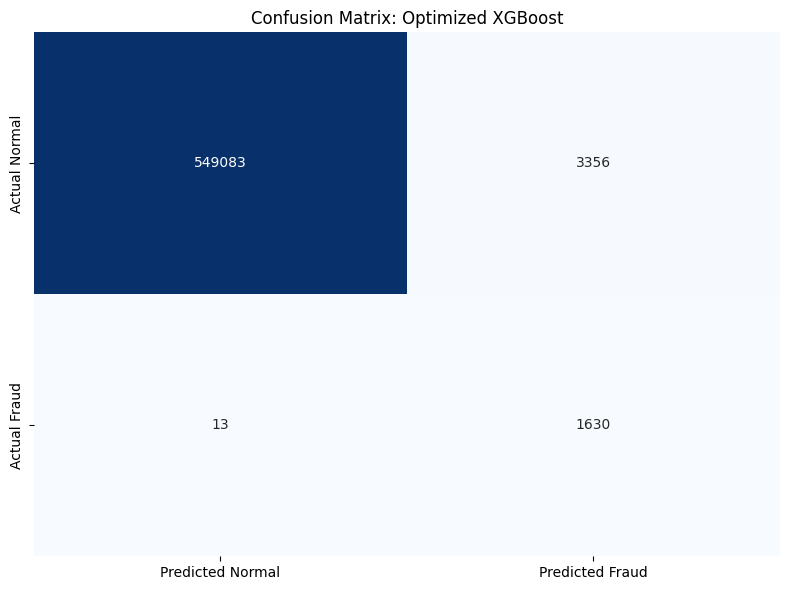

In [29]:
# Visualisation 1: Confusion Matrix for XGBoost
cm = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'])
plt.title('Confusion Matrix: Optimized XGBoost')
plt.tight_layout()
plt.show()

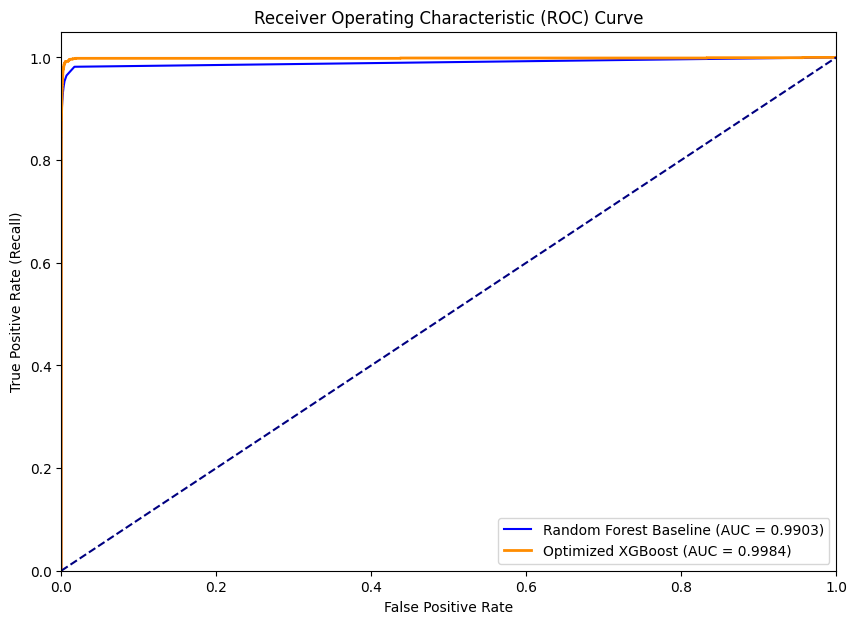

In [30]:
# Visualisation 2: ROC Curve Comparison
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(10, 7))
plt.plot(fpr_rf, tpr_rf, color='blue', label=f'Random Forest Baseline (AUC = {roc_auc_rf:.4f})')
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label=f'Optimized XGBoost (AUC = {roc_auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [32]:
# Extract feature importances from the optimized XGBoost model
importances = best_xgb_model.feature_importances_
feature_names = X_train.columns

In [33]:
# Create a DataFrame for easy sorting and plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

In [34]:
# Print the raw scores
print("Top 5 Most Important Features:")
print(feature_importance_df.head(5))

Top 5 Most Important Features:
          Feature  Importance
1   oldbalanceOrg    0.291647
2  newbalanceOrig    0.245706
4  newbalanceDest    0.209623
0          amount    0.104029
6   type_TRANSFER    0.084545


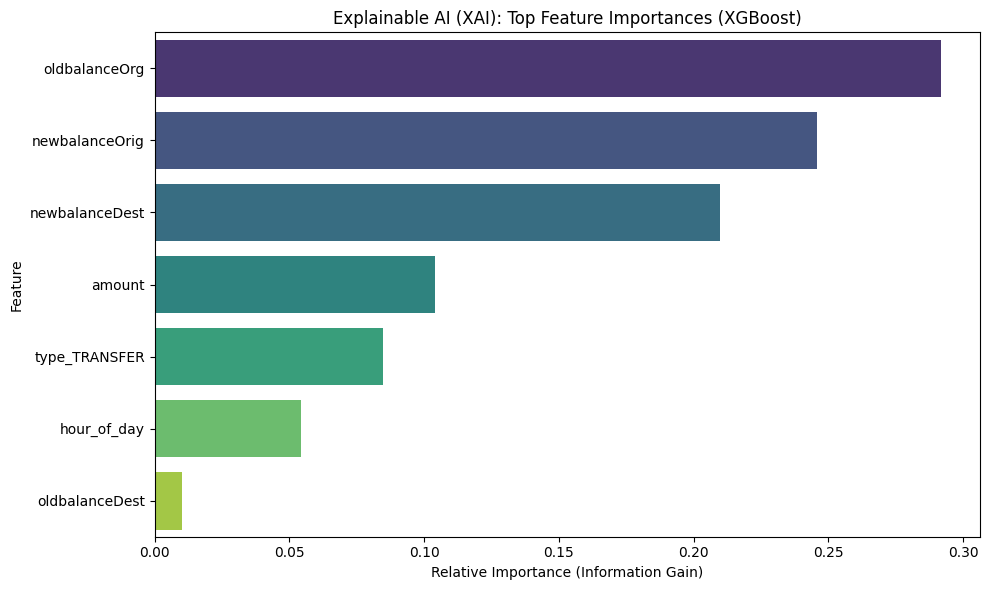

In [35]:
# Plot the Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Explainable AI (XAI): Top Feature Importances (XGBoost)')
plt.xlabel('Relative Importance (Information Gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()